# Au verification: multislice vs WPM vs ODE

Thicknes sweep for Au comparing abTEM multislice, WPM, and an adaptive ODE integrator.

In [147]:
%matplotlib widget

import os
import sys
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
from scipy.interpolate import interp1d

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from tqdm import trange
from tqdm.auto import tqdm

# add parent folder (and common src folder) to sys.path so imports can be resolved
parent = Path.cwd().parent
candidates = [parent, parent / "src"]
for p in candidates:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from jax_multislice import (
    electron_refractive_index,
    energy2wavelength,
    wpm_step_adaptive,
    Propagator as convolve2d,
    fresnel_propagation_kernel,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape

    # normalized Fourier coefficients so that a unit plane wave has C00 = 1
    C = jnp.fft.fft2(psi_xy) / (Nx * Ny)

    if use_fftshift:
        C = jnp.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return jnp.abs(C[cy + k, cx + h])   # [h,k] beam
    else:
        # unshifted indexing: negative orders wrap around
        return jnp.abs(C[k % Ny, h % Nx])

Extracted data from Klein-Gordon equation solutions for both diagrams a and b of figure 3 in doi:10.1016/j.ultramic.2008.08.008

In [148]:

# Extracted Plot data:

raw_data_Au_Beam_0_0_Klein_Gordon_MS = """0.06421232876712413, 0.9984732824427482
0.98458904109589, 0.9874045801526719
1.9049657534246576, 0.9599236641221375
2.397260273972603, 0.9431297709923665
3.4460616438356153, 0.9041984732824428
4.216609589041096, 0.8809160305343512
4.880136986301369, 0.867557251908397
5.736301369863013, 0.8641221374045802
6.6138698630137, 0.8725190839694656
7.4486301369863, 0.8858778625954199
8.197773972602743, 0.9022900763358779
8.94691780821918, 0.918320610687023
9.76027397260274, 0.9286259541984734
10.637842465753426, 0.9324427480916031
11.665239726027401, 0.9240458015267177
12.671232876712331, 0.9041984732824428
13.613013698630137, 0.8809160305343513
14.511986301369863, 0.8595419847328245
15.325342465753433, 0.8450381679389314
16.438356164383563, 0.835496183206107
17.529965753424662, 0.8381679389312977
18.728595890410965, 0.8461832061068704
19.58476027397261, 0.8515267175572521
20.71917808219178, 0.8530534351145038
21.72517123287672, 0.8473282442748091
23.073630136986306, 0.8297709923664123
24.14383561643836, 0.8118320610687024
24.807363013698637, 0.8030534351145039

"""


raw_data_Au_Beam_0_28_Klein_Gordon_FWD = """0.22062721060899548, 0.00022950819672130918
0.7942772332571906, 0.000852459016393449
1.500467420321705, 0.0018360655737704942
2.339342334788604, 0.0033770491803278707
3.0016335617428496, 0.004622950819672133
4.680202580931187, 0.008819672131147538
5.828562754792266, 0.011508196721311474
7.373218261196406, 0.013475409836065575
8.475824249959047, 0.013901639344262293
9.798479197386307, 0.013770491803278686
10.768593209394673, 0.013901639344262293
11.915700504042945, 0.014885245901639345
12.908872312333159, 0.01639344262295082
14.41020711057142, 0.01940983606557377
15.05035610682242, 0.020524590163934424
16.373974807490292, 0.02170491803278688
18.093647902391076, 0.02183606557377049
19.32792667765346, 0.02144262295081967
21.35669953065218, 0.02219672131147541
22.901379130887335, 0.024196721311475405
24.0047802160735, 0.02570491803278688
24.93111573712666, 0.02626229508196721"""


raw_data_Au_Beam_0_28_Klein_Gordon_MS = """0.06620984763060989, 0.00009836065573769898
0.8162989948053649, 0.0008196721311475447
1.478421564942515, 0.0018360655737704873
2.9133055772400027, 0.0044262295081967246
5.253876697410391, 0.009475409836065572
6.732466919170015, 0.011540983606557375
8.12178949701719, 0.012131147540983607
9.796937192201312, 0.011672131147540982
11.870355914071766, 0.013180327868852457
13.613857807846884, 0.015737704918032787
14.606836865488965, 0.016983606557377046
15.841790268019778, 0.017508196721311473
16.76733069264946, 0.016983606557377046
18.177205308352853, 0.015540983606557375
19.939813610123274, 0.014098360655737704
22.034724029259564, 0.01485245901639344
23.071144264222596, 0.015213114754098356
24.085157236341217, 0.015081967213114753
24.92234558263702, 0.014327868852459017
"""

def parse_and_interpolate(raw_data):
    # Parse the comma-separated data
    data = np.array([[float(val) for val in line.split(',')] for line in raw_data.strip().split('\n')])
    
    # Sort by the first column (x)
    data = data[data[:, 0].argsort()]
    
    x_extracted = data[:, 0]
    y_extracted = data[:, 1]

    # Create cubic interpolator
    return interp1d(x_extracted, y_extracted, kind='cubic', fill_value="extrapolate")

Beam_0_0_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_0_Klein_Gordon_MS)
Beam_0_28_Au_Klein_Gordon_FWD = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_FWD)
Beam_0_28_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_MS)


## Crystal and beam setup

In [149]:
atoms = bulk("Au", "fcc", a=4.08, cubic=True)
coarse_unitcell_gpts = (128, 128, 128)
energy = 300e3
n_cells_range = range(0, 26)

# For FCC cubic cell, there are 2 atomic planes in the z-direction.
# We want 1 slice per atomic plane.
n_slices_coarse = 2 

cell_thickness = atoms.get_cell()[2, 2]
slice_thickness_coarse = cell_thickness / 2

potential_coarse = abtem.Potential(
    atoms,
    gpts=coarse_unitcell_gpts[:2],
    slice_thickness=slice_thickness_coarse,
    projection="infinite",
    parametrization="lobato"
)

## Potential generation and probe

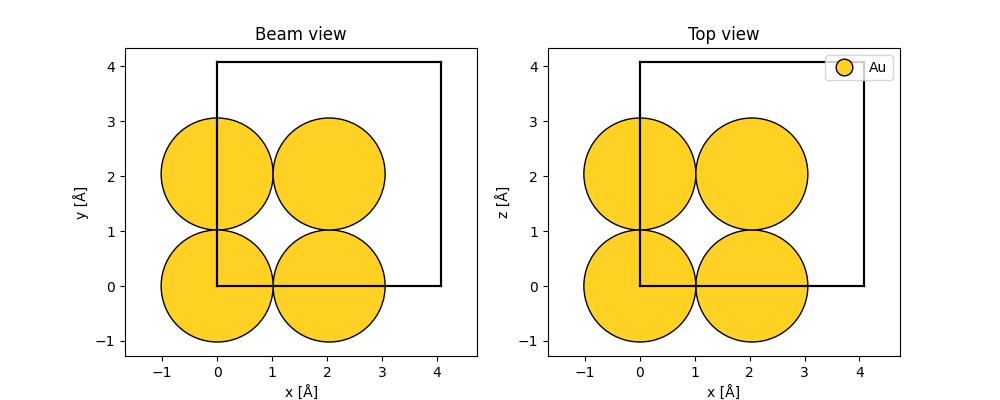

In [150]:
pot_array_coarse = potential_coarse.build(lazy=False).array / slice_thickness_coarse

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True)
plt.show()

wavelength = energy2wavelength(energy)
k0 = 2 * np.pi / wavelength

probe = abtem.PlaneWave(energy=energy)
probe.grid.match(potential_coarse)
probe_array = probe.build(lazy=False).array

## WPM helper

In [151]:
def simulate_pattern_wpm(potential, probe, dz, energy, ps):
    wavefront = probe
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n,
            dz,
            energy,
            ps,
            n_bins=256,
            power_spacing=2.0,
        )

    diffraction = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(wavefront)))
    return wavefront, diffraction


def simulate_pattern_fresnel_as(potential, probe, prop_kernel, dz):
    wavefront = probe
    wavefronts = []

    for i in range(potential.shape[0]):
        n = electron_refractive_index(potential[i], energy)
        phase_shift = jnp.exp(1j * 2 * jnp.pi * (n - 1) * dz / wavelength)
        wavefront = wavefront * phase_shift
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern



## Multislice thickness sweep (abTEM)

In [152]:
measurements_multislice = []
probe = abtem.Waves(array=probe_array, sampling=probe.sampling, energy=energy)

# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=slice_thickness_coarse,
    energy=probe.energy,
)

measurements_ms_0_0 = []
measurements_ms_0_28 = []
for i in tqdm(n_cells_range, desc="Multislice cells"):
    if i == 0:
        exit_wave = probe.array
    else: 
        exit_wave, diffraction_pattern = simulate_pattern_fresnel_as(pot_array_coarse, probe.array, fresnel_propagator, slice_thickness_coarse)

    beam_0_0 = beam_amplitude_normalized(exit_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(exit_wave, 0, 28, use_fftshift=True)
    
    measurements_ms_0_0.append(beam_0_0)
    measurements_ms_0_28.append(beam_0_28)

    probe = abtem.Waves(array=exit_wave, sampling=probe.sampling, energy=energy)

exit_wave_ms = exit_wave
measurements_multislice = np.array(measurements_multislice)


Multislice cells:   0%|          | 0/26 [00:00<?, ?it/s]

## WPM thickness sweep

In [153]:
current_wave = probe_array

measurements_wpm_0_0 = []
measurements_wpm_0_28 = []

for i in tqdm(n_cells_range, desc="WPM cells"):
    if i == 0:
        current_wave = probe_array
        diffraction_pattern = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(current_wave) / (current_wave.shape[0] * current_wave.shape[1])))
    else:
        current_wave, diffraction_pattern = simulate_pattern_wpm(
            pot_array_coarse,
            current_wave,
            slice_thickness_coarse,
            energy,
        probe.sampling,
    )

    beam_0_0 = beam_amplitude_normalized(current_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(current_wave, 0, 28, use_fftshift=True)

    measurements_wpm_0_0.append(beam_0_0)
    measurements_wpm_0_28.append(beam_0_28)

exit_wave_wpm = current_wave


WPM cells:   0%|          | 0/26 [00:00<?, ?it/s]

WPM slices: 100%|██████████| 2/2 [00:00<00:00, 95.21it/s]


## Comparison plots

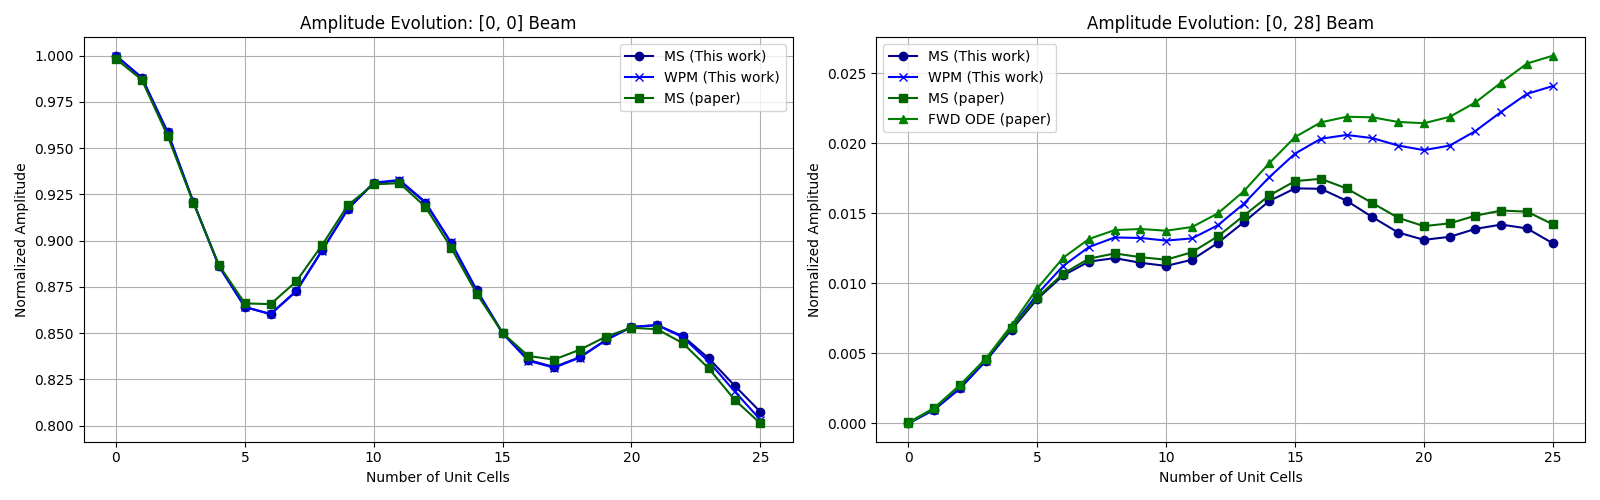

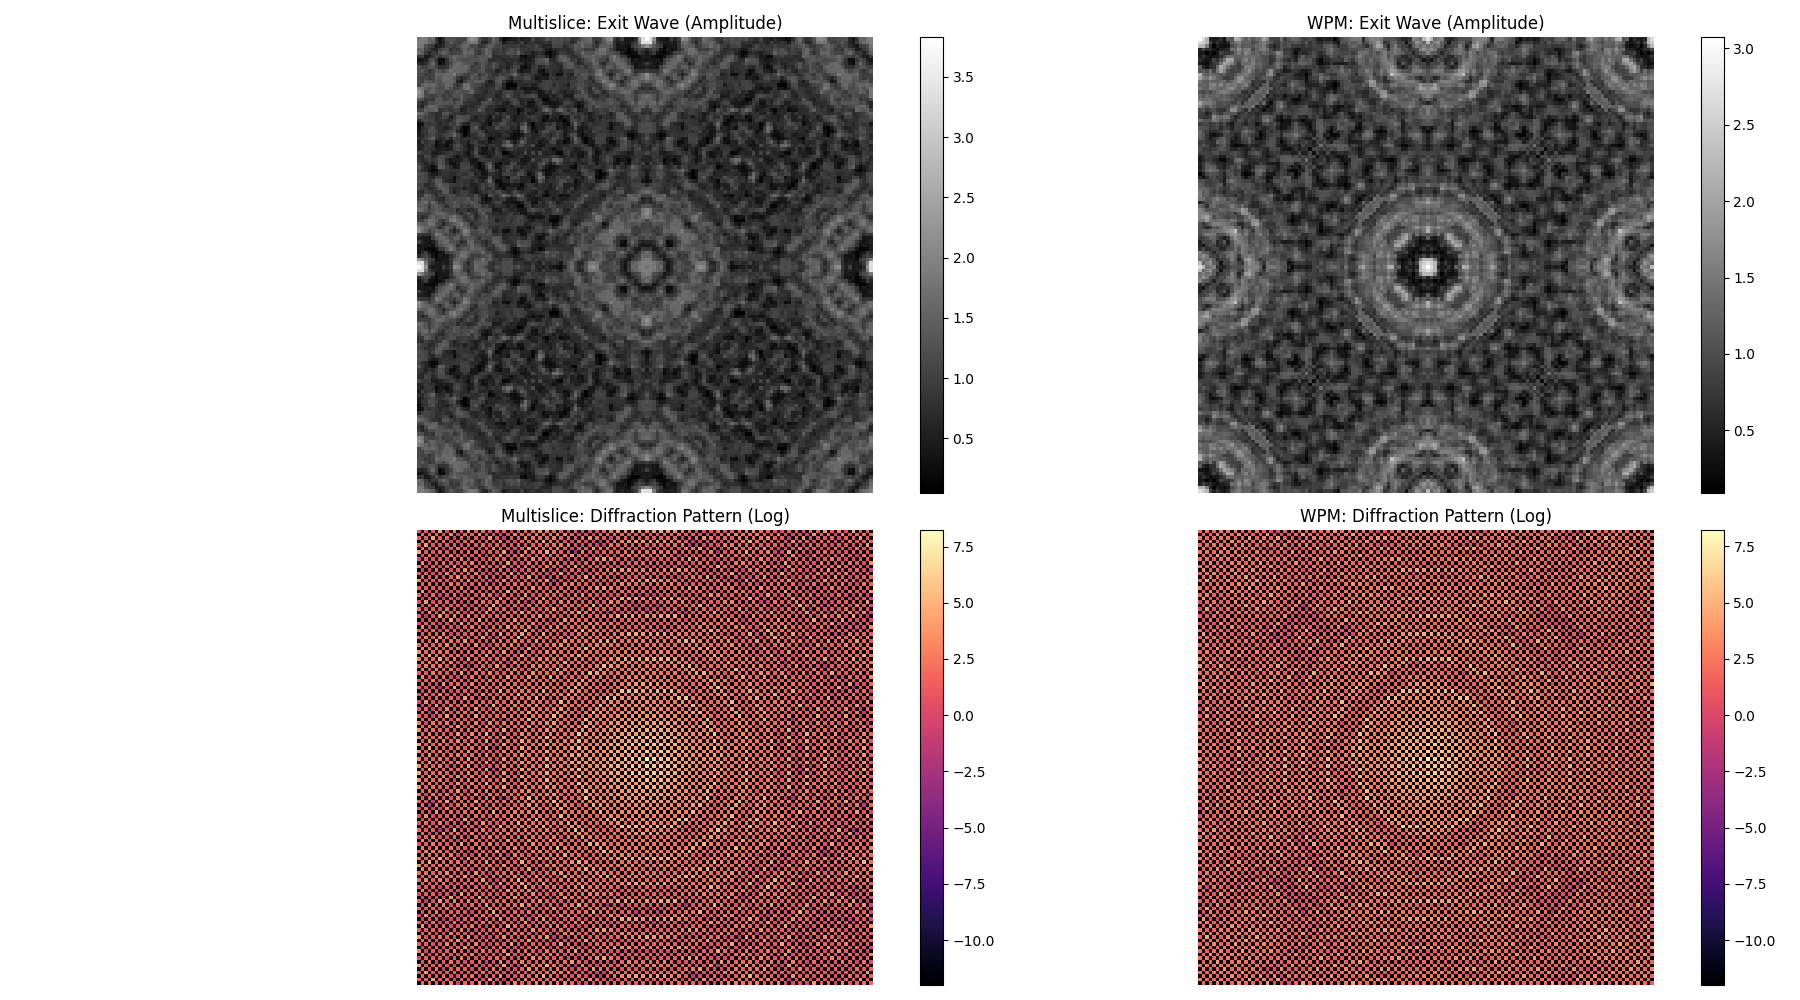

In [155]:
measurements_multislice_0_0 = np.array(measurements_ms_0_0)
measurements_multislice_paper_0_0 = Beam_0_0_Au_Klein_Gordon_MS(np.array(n_cells_range))
measurements_multislice_0_28 = np.array(measurements_ms_0_28)

measurements_fwd_ode_paper_0_28 = Beam_0_28_Au_Klein_Gordon_FWD(np.array(n_cells_range))
measurements_ms_paper_0_28 = Beam_0_28_Au_Klein_Gordon_MS(np.array(n_cells_range))
measurements_wpm_0_0 = np.array(measurements_wpm_0_0)
measurements_wpm_0_28 = np.array(measurements_wpm_0_28)

# --- Figure 1: Beam Amplitudes ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot [0,0] beam
ax1.plot(measurements_multislice_0_0, marker="o", label="MS (This work)", color='darkblue')
ax1.plot(measurements_wpm_0_0, marker="x", label="WPM (This work)", color='blue')
ax1.plot(measurements_multislice_paper_0_0, marker="s", label="MS (paper)", color='darkgreen')
ax1.set_xlabel("Number of Unit Cells")
ax1.set_ylabel("Normalized Amplitude")
ax1.set_title("Amplitude Evolution: [0, 0] Beam")
ax1.grid(True)
ax1.legend()

# Plot [0,28] beam
ax2.plot(measurements_multislice_0_28, marker="o", label="MS (This work)", color='darkblue')
ax2.plot(measurements_wpm_0_28, marker="x", label="WPM (This work)", color='blue')
ax2.plot(measurements_ms_paper_0_28, marker="s", label="MS (paper)", color='darkgreen')
ax2.plot(measurements_fwd_ode_paper_0_28, marker="^", label="FWD ODE (paper)", color='green')
ax2.set_xlabel("Number of Unit Cells")
ax2.set_ylabel("Normalized Amplitude")
ax2.set_title("Amplitude Evolution: [0, 28] Beam")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
# Save the first figure as PDF
fig1.savefig("Au_beam_amplitudes.pdf", bbox_inches='tight')

# --- Figure 2: Wavefields ---
fig2, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Multislice ---
ms_wave = exit_wave_ms
ms_ft = np.fft.fftshift(np.fft.fft2(ms_wave))
ms_log_int = np.log10(np.abs(ms_ft)**2 + 1e-12)

im0 = axes[0, 0].imshow(np.abs(ms_wave), cmap="gray")
axes[0, 0].set_title("Multislice: Exit Wave (Amplitude)")
axes[0, 0].axis("off")
fig2.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[1, 0].imshow(ms_log_int, cmap="magma")
axes[1, 0].set_title("Multislice: Diffraction Pattern (Log)")
axes[1, 0].axis("off")
fig2.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# --- WPM ---
wpm_wave = np.array(exit_wave_wpm)
wpm_ft = np.fft.fftshift(np.fft.fft2(wpm_wave))
wpm_log_int = np.log10(np.abs(wpm_ft)**2 + 1e-12)

im2 = axes[0, 1].imshow(np.abs(wpm_wave), cmap="gray")
axes[0, 1].set_title("WPM: Exit Wave (Amplitude)")
axes[0, 1].axis("off")
fig2.colorbar(im2, ax=axes[0, 1], fraction=0.046)

im3 = axes[1, 1].imshow(wpm_log_int, cmap="magma")
axes[1, 1].set_title("WPM: Diffraction Pattern (Log)")
axes[1, 1].axis("off")
fig2.colorbar(im3, ax=axes[1, 1], fraction=0.046)


plt.tight_layout()
# Save the second figure as PDF
fig2.savefig("Au_wavefields.pdf", bbox_inches='tight')
